# U08 — Analisis de navegacion con cadenas de Markov (rutas frecuentes y puntos de fuga)

**Escenario:** entender como se mueven los usuarios entre las pantallas de la
plataforma (home, mapa de niveles, leccion, ejercicio, resultado, logros,
leaderboard, perfil, configuracion, salir) para detectar rutas frecuentes y
"puntos de fuga" (paginas desde las que los usuarios abandonan la sesion con mayor
probabilidad).

Se modela la navegacion como una **cadena de Markov de primer orden**: la
probabilidad de la siguiente pagina depende solo de la pagina actual (no de todo el
historial). El estado `salir` es absorbente: una vez alcanzado termina la sesion.

Como enfoque complementario ("clustering de secuencias" sugerido por la guia),
tambien se agrupan las sesiones completas segun su "forma" (cuantas veces visitaron
cada pagina) usando K-Means.


In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# nbconvert ejecuta el kernel con cwd = carpeta del notebook (notebooks/unsupervised);
# nos posicionamos en la raiz del repo para que las rutas relativas ("data/...", "models/...") funcionen.
if (Path.cwd() / "data").exists() is False and (Path.cwd().parents[1] / "data").exists():
    os.chdir(Path.cwd().parents[1])
print("cwd:", Path.cwd())

sns.set_theme(style="whitegrid")
RANDOM_STATE = 2026

nav = pd.read_csv("data/processed/navigation_events.csv")
nav = nav.sort_values(["session_id", "step_index"]).reset_index(drop=True)
print(nav.shape)
nav.head()


cwd: C:\Users\tass1\Videos\tutunakun\tutunakun
(84215, 5)


,session_id,user_id,step_index,page,timestamp
0,1,637,0,home,2026-04-10 23:37:07
1,1,637,1,home,2026-04-10 23:37:27
2,1,637,2,mapa_niveles,2026-04-10 23:37:47
3,1,637,3,leccion,2026-04-10 23:38:07
4,1,637,4,ejercicio,2026-04-10 23:38:27


In [2]:
STATES = ["home", "mapa_niveles", "leccion", "ejercicio", "resultado",
          "logros", "leaderboard", "perfil", "configuracion", "salir"]
ABSORBING_STATE = "salir"
START_STATE = "home"

assert set(nav["page"].unique()) == set(STATES)
print("Sesiones unicas:", nav["session_id"].nunique())
print("Eventos totales:", len(nav))


Sesiones unicas: 8000
Eventos totales: 84215


## 1. Exploracion de datos (EDA)

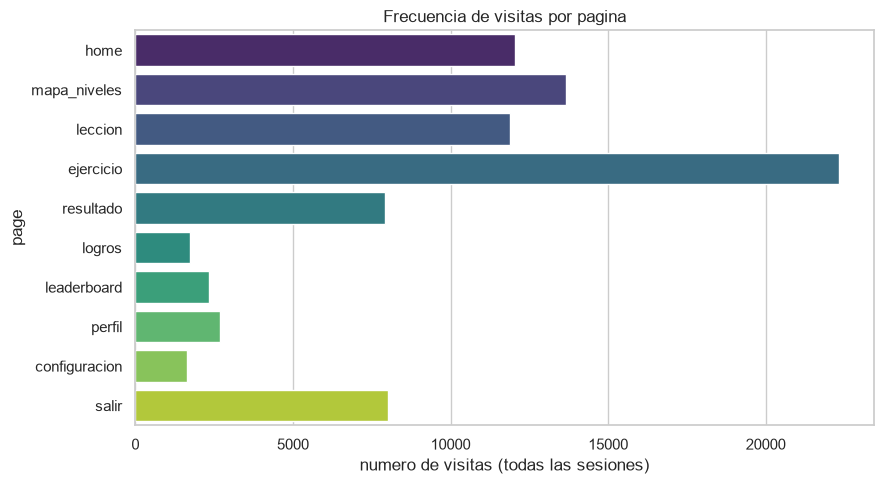

page
home             12031
mapa_niveles     13673
leccion          11870
ejercicio        22319
resultado         7925
logros            1741
leaderboard       2329
perfil            2687
configuracion     1640
salir             8000
Name: count, dtype: int64

In [3]:
page_counts = nav["page"].value_counts().reindex(STATES)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=page_counts.values, y=page_counts.index, hue=page_counts.index,
            palette="viridis", ax=ax, legend=False)
ax.set_xlabel("numero de visitas (todas las sesiones)")
ax.set_title("Frecuencia de visitas por pagina")
plt.tight_layout()
plt.show()

page_counts


**Interpretacion:** `ejercicio` y `mapa_niveles` concentran la mayor parte de
las visitas (son el nucleo de la experiencia de aprendizaje), mientras que
`configuracion` y `logros` son las paginas menos visitadas — consistente con ser
pantallas secundarias que el usuario visita ocasionalmente.

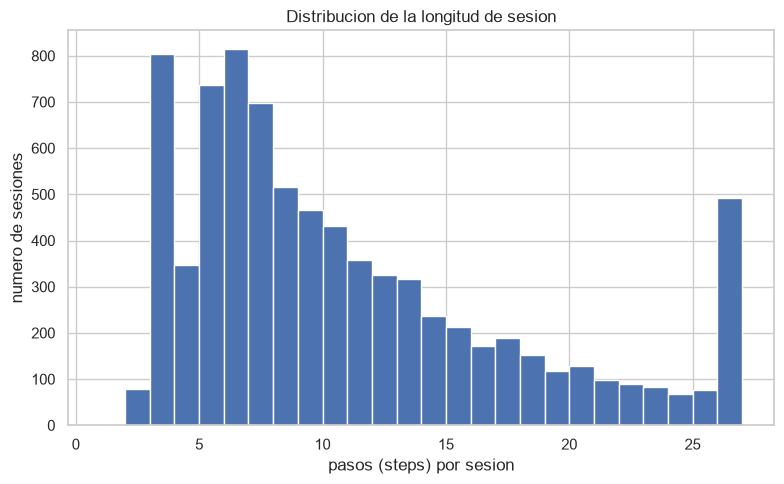

count    8000.000000
mean       10.526875
std         6.625558
min         2.000000
25%         6.000000
50%         9.000000
75%        14.000000
max        26.000000
dtype: float64

In [4]:
session_lengths = nav.groupby("session_id").size()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(session_lengths, bins=range(1, session_lengths.max() + 2), color="#4C72B0")
ax.set_xlabel("pasos (steps) por sesion")
ax.set_ylabel("numero de sesiones")
ax.set_title("Distribucion de la longitud de sesion")
plt.tight_layout()
plt.show()

session_lengths.describe()


In [5]:
drop_off_rows = []
for state in STATES:
    if state == ABSORBING_STATE:
        continue
    # para cada ocurrencia de `state` que NO sea el ultimo paso de su sesion,
    # ver si el siguiente paso es 'salir'
    nav_sorted = nav
    nxt = nav_sorted.groupby("session_id")["page"].shift(-1)
    mask_state = nav_sorted["page"] == state
    total_occurrences = mask_state.sum()
    exits_after = ((nxt == ABSORBING_STATE) & mask_state).sum()
    rate = exits_after / total_occurrences if total_occurrences else np.nan
    drop_off_rows.append({"page": state, "occurrences": int(total_occurrences),
                           "exits_immediately_after": int(exits_after), "drop_off_rate": rate})

drop_off_df = pd.DataFrame(drop_off_rows).sort_values("drop_off_rate", ascending=False).reset_index(drop=True)
drop_off_df


,page,occurrences,exits_immediately_after,drop_off_rate
0,logros,1741,815,0.468122
1,leaderboard,2329,922,0.395878
2,configuracion,1640,599,0.365244
3,resultado,7925,2248,0.283659
4,perfil,2687,588,0.218831
5,ejercicio,22319,2282,0.102245
6,leccion,11870,204,0.017186
7,mapa_niveles,13673,201,0.014701
8,home,12031,141,0.011720


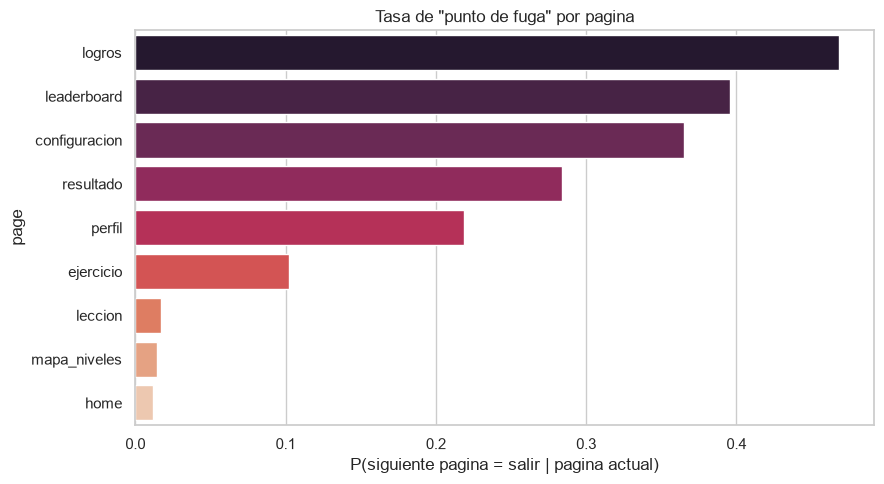

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=drop_off_df, x="drop_off_rate", y="page", hue="page", palette="rocket",
            ax=ax, legend=False)
ax.set_xlabel("P(siguiente pagina = salir | pagina actual)")
ax.set_title('Tasa de "punto de fuga" por pagina')
plt.tight_layout()
plt.show()


**Interpretacion (puntos de fuga):** las paginas con mayor `drop_off_rate` son
los lugares desde donde el usuario sale de la app con mayor frecuencia inmediatamente
despues de visitarlas. Esto es distinto de simplemente ser una pagina popular: una
pagina puede tener pocas visitas totales pero una tasa de fuga muy alta (indicio de
friccion), o muchas visitas con fuga baja (pagina de transito saludable). El top-3
se reporta formalmente en la seccion 3.

## 2. Split de sesiones fit/holdout (80/20) y estabilidad de la matriz de transicion

In [7]:
def build_transition_matrix(df, states):
    counts = pd.DataFrame(0, index=states, columns=states, dtype=float)
    df_sorted = df.sort_values(["session_id", "step_index"])
    next_page = df_sorted.groupby("session_id")["page"].shift(-1)
    pairs = pd.DataFrame({"cur": df_sorted["page"], "nxt": next_page}).dropna()
    tally = pairs.groupby(["cur", "nxt"]).size()
    for (cur, nxt), n in tally.items():
        counts.loc[cur, nxt] = n
    row_sums = counts.sum(axis=1)
    matrix = counts.div(row_sums, axis=0)
    # Estados sin transiciones salientes observadas (ninguna fila deberia quedar en 0,
    # salvo el estado absorbente 'salir', que no tiene sucesor por diseno):
    # documentamos la decision de dejar esa fila en 0 (no se define auto-transicion),
    # ya que el consumidor de la API debe tratar 'salir' como estado terminal.
    matrix = matrix.fillna(0.0)
    return matrix

session_ids = nav["session_id"].unique()
fit_ids, holdout_ids = train_test_split(session_ids, test_size=0.2, random_state=RANDOM_STATE)
print("fit sessions:", len(fit_ids), " holdout sessions:", len(holdout_ids))

nav_fit = nav[nav["session_id"].isin(fit_ids)]
nav_holdout = nav[nav["session_id"].isin(holdout_ids)]

matrix_fit = build_transition_matrix(nav_fit, STATES)
matrix_holdout = build_transition_matrix(nav_holdout, STATES)

mean_abs_diff = (matrix_fit - matrix_holdout).abs().values.mean()
print(f"Diferencia media absoluta entre matrices fit vs holdout: {mean_abs_diff:.5f}")


fit sessions: 6400  holdout sessions: 1600
Diferencia media absoluta entre matrices fit vs holdout: 0.00501


**Interpretacion:** la matriz de transicion se estima de forma independiente en
el 80% (fit) y el 20% (holdout) de las sesiones. Una diferencia media absoluta baja
(cercana a 0) indica que las probabilidades de transicion son estables y no dependen
de la muestra particular usada — es decir, la cadena de Markov estimada generaliza
bien, en vez de ser un artefacto de overfitting a un subconjunto de sesiones. Esto NO
es una metrica de accuracy supervisada; es un chequeo de estabilidad estadistica.

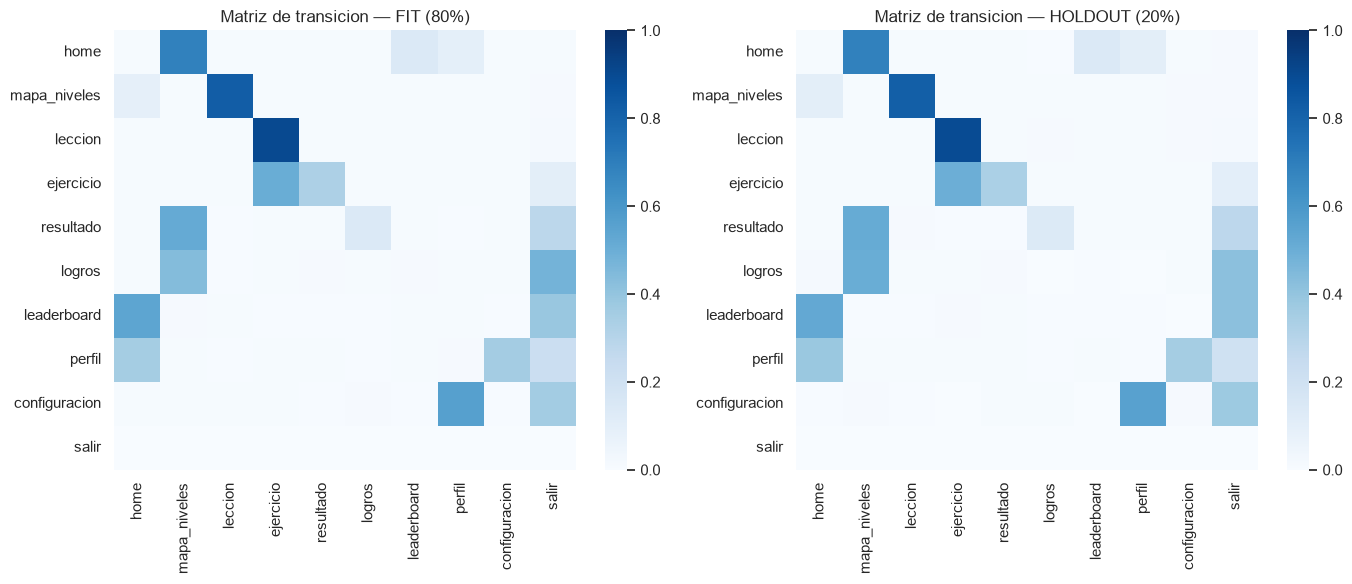

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(matrix_fit, annot=False, cmap="Blues", ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Matriz de transicion — FIT (80%)")
sns.heatmap(matrix_holdout, annot=False, cmap="Blues", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Matriz de transicion — HOLDOUT (20%)")
plt.tight_layout()
plt.show()


## 3. Matriz de transicion final (dataset completo), rutas frecuentes y puntos de fuga

In [9]:
full_matrix = build_transition_matrix(nav, STATES)
full_matrix.round(3)


,home,mapa_niveles,leccion,ejercicio,resultado,logros,leaderboard,perfil,configuracion,salir
home,0.010,0.689,0.010,0.010,0.010,0.010,0.143,0.098,0.009,0.012
mapa_niveles,0.093,0.009,0.825,0.008,0.010,0.010,0.010,0.009,0.011,0.015
leccion,0.010,0.011,0.010,0.901,0.011,0.010,0.010,0.010,0.010,0.017
ejercicio,0.009,0.009,0.009,0.504,0.332,0.009,0.009,0.009,0.009,0.102
resultado,0.009,0.516,0.008,0.008,0.008,0.140,0.009,0.008,0.010,0.284
logros,0.010,0.452,0.008,0.011,0.013,0.007,0.013,0.009,0.009,0.468
leaderboard,0.539,0.011,0.009,0.007,0.007,0.007,0.010,0.009,0.006,0.396
perfil,0.361,0.009,0.008,0.009,0.010,0.007,0.008,0.011,0.358,0.219
configuracion,0.009,0.012,0.009,0.009,0.007,0.013,0.006,0.564,0.008,0.365
salir,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [10]:
nav_sorted = nav.sort_values(["session_id", "step_index"])
next_page_full = nav_sorted.groupby("session_id")["page"].shift(-1)
pairs_full = pd.DataFrame({"cur": nav_sorted["page"], "nxt": next_page_full}).dropna()
pair_counts = pairs_full.groupby(["cur", "nxt"]).size().sort_values(ascending=False)

top3_paths = pair_counts.head(3)
print("Top-3 transiciones (pagina -> pagina) mas frecuentes:")
for (cur, nxt), n in top3_paths.items():
    print(f"  {cur} -> {nxt}: {n} veces")

top_paths_list = [{"from": cur, "to": nxt, "count": int(n)} for (cur, nxt), n in top3_paths.items()]


Top-3 transiciones (pagina -> pagina) mas frecuentes:
  mapa_niveles -> leccion: 11284 veces
  ejercicio -> ejercicio: 11249 veces
  leccion -> ejercicio: 10699 veces


In [11]:
# Top-3 puntos de fuga (excluye 'salir' mismo, que no tiene salientes)
top3_dropoff = drop_off_df.head(3)
print('Top-3 "puntos de fuga" (mayor probabilidad de salir inmediatamente despues):')
for _, row in top3_dropoff.iterrows():
    print(f"  {row['page']}: {row['drop_off_rate']:.2%} ({row['exits_immediately_after']}/{row['occurrences']})")

drop_off_points_list = top3_dropoff.to_dict(orient="records")


Top-3 "puntos de fuga" (mayor probabilidad de salir inmediatamente despues):
  logros: 46.81% (815/1741)
  leaderboard: 39.59% (922/2329)
  configuracion: 36.52% (599/1640)


**Rutas frecuentes:** las transiciones mas comunes reflejan el flujo esperado
de la app (por ejemplo, moverse entre `mapa_niveles` y `leccion`/`ejercicio`, y de
`ejercicio` a `resultado`). **Puntos de fuga:** las paginas listadas arriba son
aquellas desde las que, condicionado a haberlas visitado, el usuario sale de la
sesion con mayor probabilidad — candidatas a revisar UX o agregar CTAs de
retencion.

## 4. Clustering de secuencias (bag-of-states + K-Means)

In [12]:
bag_of_states = (
    nav.groupby(["session_id", "page"]).size().unstack(fill_value=0).reindex(columns=STATES, fill_value=0)
)
print(bag_of_states.shape)
bag_of_states.head()


(8000, 10)


page,home,mapa_niveles,leccion,ejercicio,resultado,logros,leaderboard,perfil,configuracion,salir
session_id,,,,,,,,,,
1,2,1,1,7,1,0,0,0,0,1
2,1,1,1,2,1,0,0,0,0,1
3,1,3,3,10,2,0,0,0,0,1
4,1,3,2,3,3,1,0,0,0,1
5,2,3,1,6,1,0,1,0,0,1


In [13]:
scaler_seq = StandardScaler()
X_bag = scaler_seq.fit_transform(bag_of_states.values)

sil_scores = {}
inertias = {}
kmeans_models = {}
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_bag)
    sil = silhouette_score(X_bag, labels_k)
    sil_scores[k] = sil
    inertias[k] = km.inertia_
    kmeans_models[k] = (km, labels_k)
    print(f"k={k}: silhouette={sil:.4f}  inertia={km.inertia_:.1f}")

best_k = max(sil_scores, key=sil_scores.get)
print("Mejor k por silhouette:", best_k)
best_km, best_labels = kmeans_models[best_k]


k=3: silhouette=0.3687  inertia=43582.5


k=4: silhouette=0.2752  inertia=38461.1
Mejor k por silhouette: 3


In [14]:
bag_of_states_labeled = bag_of_states.copy()
bag_of_states_labeled["cluster"] = best_labels

cluster_profile = bag_of_states_labeled.groupby("cluster")[STATES].mean().round(2)
cluster_profile["n_sessions"] = bag_of_states_labeled.groupby("cluster").size()
cluster_profile


page,home,mapa_niveles,leccion,ejercicio,resultado,logros,leaderboard,perfil,configuracion,salir,n_sessions
cluster,,,,,,,,,,,
0,2.28,1.85,1.45,2.43,0.82,0.16,0.38,2.09,1.57,1.0,655
1,1.25,1.04,0.91,1.62,0.53,0.13,0.26,0.16,0.08,1.0,5473
2,1.98,3.62,3.18,6.32,2.40,0.49,0.34,0.25,0.10,1.0,1872


**Interpretacion de clusters (ejemplo basado en los perfiles anteriores):**
observando las medias de visitas por pagina en cada cluster se pueden identificar
"formas" de sesion tipicas — por ejemplo, un cluster con alto promedio de visitas a
`ejercicio` y pocas paginas visitadas en total corresponde a sesiones cortas y
orientadas a la practica ("entra, hace un ejercicio, sale"), mientras que un cluster
con conteos altos y repartidos entre `mapa_niveles`, `logros`, `leaderboard` y
`perfil` corresponde a sesiones largas y exploratorias donde el usuario navega por
varias secciones antes de concentrarse en el contenido. Los valores concretos de cada
cluster se listan en la tabla `cluster_profile` de arriba.

## 5. Exportacion del artefacto

In [15]:
import os
os.makedirs("models/serialized", exist_ok=True)

joblib.dump({
    "transition_matrix": full_matrix,
    "states": STATES,
    "start_state": START_STATE,
    "absorbing_state": ABSORBING_STATE,
    "top_paths": top_paths_list,
    "drop_off_points": drop_off_points_list,
}, "models/serialized/navigation_markov.joblib")

metadata = {
    "model_name": "navigation_markov",
    "version": "1.0.0",
    "algorithm": "first_order_markov_chain",
    "task": "sequence_analysis",
    "states": STATES,
    "metrics": {
        "train_holdout_matrix_mean_abs_diff": float(mean_abs_diff),
        "kmeans_silhouette_k3": float(sil_scores[3]),
        "kmeans_silhouette_k4": float(sil_scores[4]),
    },
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "notes": (
        "Uso: dado un current_state, transition_matrix.loc[current_state] entrega la "
        "distribucion de probabilidad de la siguiente pagina (Serie indexada por pagina, "
        "suma 1.0, salvo la fila 'salir' que queda en 0 por ser estado absorbente sin "
        "transicion saliente definida). 'top_paths' son las transiciones de 2 pasos mas "
        "frecuentes y 'drop_off_points' son las paginas con mayor probabilidad de fuga "
        "inmediata, utiles para alertas en un dashboard de retencion."
    ),
}
with open("models/serialized/navigation_markov_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(json.dumps(metadata, indent=2, ensure_ascii=False))


{
  "model_name": "navigation_markov",
  "version": "1.0.0",
  "algorithm": "first_order_markov_chain",
  "task": "sequence_analysis",
  "states": [
    "home",
    "mapa_niveles",
    "leccion",
    "ejercicio",
    "resultado",
    "logros",
    "leaderboard",
    "perfil",
    "configuracion",
    "salir"
  ],
  "metrics": {
    "train_holdout_matrix_mean_abs_diff": 0.00500943367357889,
    "kmeans_silhouette_k3": 0.36868302087830296,
    "kmeans_silhouette_k4": 0.27524325655171955
  },
  "trained_at": "2026-08-01T01:05:40.427854+00:00",
  "notes": "Uso: dado un current_state, transition_matrix.loc[current_state] entrega la distribucion de probabilidad de la siguiente pagina (Serie indexada por pagina, suma 1.0, salvo la fila 'salir' que queda en 0 por ser estado absorbente sin transicion saliente definida). 'top_paths' son las transiciones de 2 pasos mas frecuentes y 'drop_off_points' son las paginas con mayor probabilidad de fuga inmediata, utiles para alertas en un dashboard de r

## 6. Verificacion final: recargar el artefacto y predecir la siguiente pagina

In [16]:
loaded = joblib.load("models/serialized/navigation_markov.joblib")
loaded_matrix = loaded["transition_matrix"]

current_state = "leccion"
next_page_probs = loaded_matrix.loc[current_state].sort_values(ascending=False)
top3_next = next_page_probs.head(3)

print(f"Dado current_state = '{current_state}', las 3 paginas siguientes mas probables son:")
for page, prob in top3_next.items():
    print(f"  {page}: {prob:.2%}")

top3_next


Dado current_state = 'leccion', las 3 paginas siguientes mas probables son:
  ejercicio: 90.13%
  salir: 1.72%
  resultado: 1.06%


ejercicio    0.901348
salir        0.017186
resultado    0.010615
Name: leccion, dtype: float64